<a href="https://colab.research.google.com/github/stephanycf/Desenvolvimento/blob/master/03C_2026_Stephany.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercício 3C - Mapas Coropléticos e Análise de Dados

Para essa parte, usamos os daods dos alvarás de Curitiba disponíveis no portal de dados abertos da cidade: https://www.curitiba.pr.gov.br/dadosabertos/busca/

Os dados foram filtrados por atividade (estacionamento), exportados para csv e geocodificados em lote pelo Google My Maps (máximo 2000 pontos), e baixado em formato KMZ. Para passar o resultado para o formato GeoJSON, foi usado o Google Earth para re-exportar os dados para KML, e depois usada a extensão KML Tools para abrir no QGIS e exportar para Geojson.


In [2]:
# Preparando o ambiente no Google Drive:

#importando a biblioteca
from google.colab import drive

# Isso irá pedir sua autorização
drive.mount('/content/drive')

# Agora, seu Drive estará disponível em: /content/drive/My Drive

Mounted at /content/drive


In [3]:
import geopandas as gpd

# Ler os dados
polygons = gpd.read_file('/content/drive/My Drive/AULA_SILVANA/bairros.geojson')
points = gpd.read_file('/content/drive/My Drive/AULA_SILVANA/estacion.geojson')

print (polygons.head())
print (points.head())

# Essa cópia é feita pois os pontos serão designados aos polígonos dos bairros
pts = points.copy()
pts_in_polys = []

# Conta quantos pontos há em cada polígono
for i, poly in polygons.iterrows():

    pts_in_this_poly = []

    for j, pt in pts.iterrows():
        if poly.geometry.contains(pt.geometry):
            pts_in_this_poly.append(pt.geometry)
            pts = pts.drop([j])

    pts_in_polys.append(len(pts_in_this_poly))
print (pts_in_polys)

# Adiciona o número de pontos ao data frame dos polígonos
polygons['number of points'] = pts_in_polys

#Mostra a tabela
print (polygons.head())
# Mostra estatísticas básicas
polygons.describe()



   OBJECTID  CODIGO               TIPO         NOME  \
0       111    29.0  DIVISA DE BAIRROS    SEMINÁRIO   
1       112    23.0  DIVISA DE BAIRROS  GUABIROTUBA   
2       113    27.0  DIVISA DE BAIRROS       PORTÃO   
3       115    45.0  DIVISA DE BAIRROS    MOSSUNGUÊ   
4       116    24.0  DIVISA DE BAIRROS  PRADO VELHO   

                          FONTE  CD_REGIONA                 NM_REGIONA  \
0  Decreto Municipal 774 / 1975         7.0            REGIONAL PORTÃO   
1  Decreto Municipal 774 / 1975         3.0            REGIONAL CAJURU   
2  Decreto Municipal 774 / 1975         7.0            REGIONAL PORTÃO   
3  Decreto Municipal 774 / 1975         5.0  REGIONAL SANTA FELICIDADE   
4  Decreto Municipal 774 / 1975         1.0            REGIONAL MATRIZ   

     SHAPE_AREA     SHAPE_LEN  \
0  2.123845e+06   7068.306546   
1  2.654431e+06   6576.157173   
2  5.858496e+06  10839.074473   
3  3.365441e+06   9125.525056   
4  2.434125e+06   7089.468068   

                         

,OBJECTID,CODIGO,CD_REGIONA,SHAPE_AREA,SHAPE_LEN,number of points
count,75.000000,75.000000,75.000000,7.500000e+01,75.000000,75.000000
mean,113.000000,38.000000,4.773333,5.795789e+06,11392.541485,0.946667
std,21.794495,21.794495,3.286226,6.373382e+06,6793.481475,1.609879
min,76.000000,1.000000,1.000000,8.754828e+05,4057.149108,0.000000
25%,94.500000,19.500000,2.000000,2.137563e+06,6949.094972,0.000000
50%,113.000000,38.000000,4.000000,3.593404e+06,9153.606344,0.000000
75%,131.500000,56.500000,7.000000,7.324647e+06,13997.875347,1.000000
max,150.000000,75.000000,12.000000,4.427339e+07,48571.574122,7.000000


## Agora, criamos o mapa:

In [4]:

import folium
import geopandas as gpd


# Criar mapa centrado
m_pontos = folium.Map(location=[points.geometry.y.mean(), points.geometry.x.mean()], zoom_start=11)

# ícones: https://getbootstrap.com/docs/3.3/components/

# Adicionar pontos simples
for _, row in points.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=str(row),
        icon=folium.Icon(color='blue', icon='flag')
    ).add_to(m_pontos)

m_pontos



In [5]:

from folium.plugins import MarkerCluster

m_cluster = folium.Map(location=[points.geometry.y.mean(), points.geometry.x.mean()], zoom_start=10)

marker_cluster = MarkerCluster().add_to(m_cluster)
for _, row in points.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=str(row)
    ).add_to(marker_cluster)

m_cluster


In [6]:

from folium.plugins import HeatMap

m_heat = folium.Map(location=[points.geometry.y.mean(), points.geometry.x.mean()], zoom_start=10)

heat_data = [[row.geometry.y, row.geometry.x] for _, row in points.iterrows()]
HeatMap(heat_data).add_to(m_heat)

m_heat


In [7]:

from folium import FeatureGroup, LayerControl

m_final = folium.Map(location=[points.geometry.y.mean(), points.geometry.x.mean()], zoom_start=10)

# Camada de pontos simples
fg_pontos = FeatureGroup(name="Pontos Simples")
for _, row in points.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=str(row),
        icon=folium.Icon(color='blue')
    ).add_to(fg_pontos)

# Camada de cluster
fg_cluster = FeatureGroup(name="Cluster")
cluster_group = MarkerCluster()
for _, row in points.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=str(row)
    ).add_to(cluster_group)
fg_cluster.add_child(cluster_group)

# Camada de calor
fg_heat = FeatureGroup(name="Mapa de Calor")
HeatMap(heat_data).add_to(fg_heat)

# Adicionar todas as camadas ao mapa final
m_final.add_child(fg_pontos)
m_final.add_child(fg_cluster)
m_final.add_child(fg_heat)

# Controle de camadas
LayerControl().add_to(m_final)

m_final


In [ ]:
import folium

m = folium.Map (location = [-25.5,-49.3],
                              zoom_start =  11
               )

bins = list(polygons['number of points'].quantile([0, 0.25, 0.5, 0.75, 1]))

folium.Choropleth(
 geo_data=polygons,
 name='estacionamentos por bairro',
 columns=['OBJECTID', 'number of points'],
 data=polygons,
 key_on='feature.properties.OBJECTID',
 fill_color='OrRd',
 legend_name='estacionamentos por bairro',
 bins=bins,
 reset=True
).add_to(m)

folium.LayerControl().add_to(m)
m.save("/content/drive/My Drive/AULA_SILVANA/estacion.html")
m

## E um gráfico

/tmp/ipykernel_518/3024694075.py:4: FutureWarning: The provided callable <function median at 0x7c987f989800> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  result = polygons.groupby(["NOME"])['number of points'].aggregate(np.median).reset_index().sort_values('number of points')


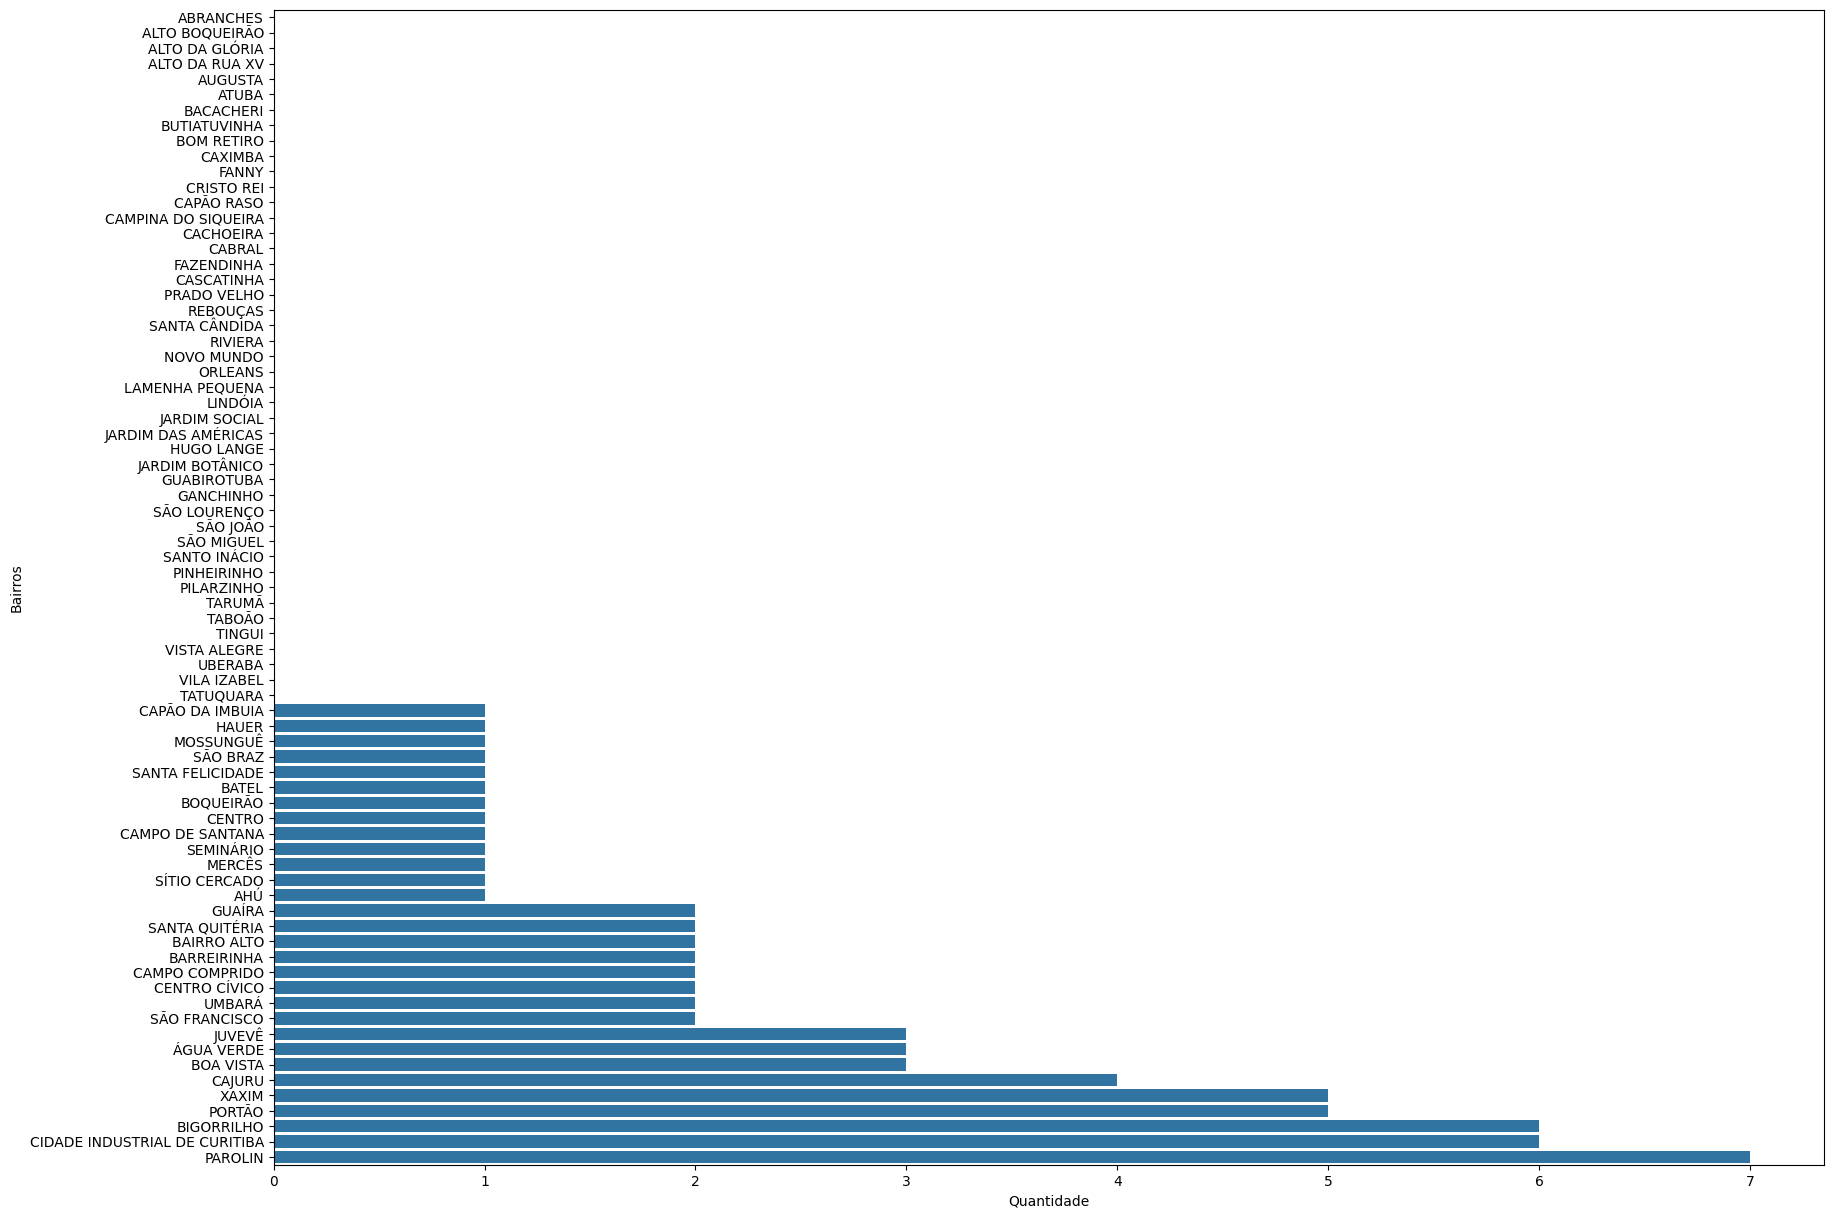

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns #faz um gráfico mais bonitinho
import numpy as np
result = polygons.groupby(["NOME"])['number of points'].aggregate(np.median).reset_index().sort_values('number of points')
plt.figure(figsize=(20,15))
sns.barplot(y='NOME',x='number of points', data = result)
plt.xlabel('Quantidade')
plt.ylabel('Bairros')
plt.show()
